# 일주일 데이터로 Lifetime을 예측하라고요? — Lifetime 추정 실습

유저 한 명이 가입 후 이탈 전까지 평균 며칠을 활동하는가 — 이 **Lifetime**은
`D1 + D2 + ... + D365` 리텐션의 합, 즉 *리텐션 곡선 아래의 면적*과 같습니다.
문제는 1년을 기다리지 않고 **초기 7일치 데이터**만으로 그 면적을 메워야 한다는 점입니다.

이 노트북은 같은 신규 코호트의 7일 관측치에 대해 세 가지 추정법을 차례로 적용하고,
마지막에 세 답을 한 표에서 비교합니다.

| 방법 | D8~D365를 어디서 가져오나 | 모델 가정 |
| :-- | :-- | :-- |
| **4.6.2. 이탈률 휴리스틱** | 등비급수로 외삽 | 강함 (이탈률 안정화) |
| **4.6.3. 리텐션 카탈로그 매칭** | 사전 계산된 카탈로그에서 매칭 | 중간 (멱함수 카탈로그) |
| **4.6.4. 장기 코호트 직접 측정** | 1년 전 코호트 실측 | 약함 (7일 면적 비례) |


## 4.6.1. 실습용 데이터 준비

아래 셀은 의존성을 설치하고 라이브러리를 불러옵니다. 데이터가 없다면 먼저 터미널에서
`python generate_data.py` 를 실행해 예시 데이터(`data/cohort_retention.csv`)를 만들어 주세요.

> **[내 데이터 적용]** `DAYS` 는 Lifetime을 며칠까지 합산할지입니다. 365일 뒤에도 리텐션이
> 높게 남는 서비스라면 730·1095로 늘립니다.


In [ ]:
# 의존성 설치
%pip install -q -r requirements.txt

# 실습용 데이터베이스 세팅
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()

DAYS = 365   # lifetime은 1년치 리텐션 합으로 근사

### 신규 코호트 데이터

실습용 D0~D7 관측 리텐션 데이터(`cohort_retention.csv`)를 DuckDB 테이블로 등록하고 조회합니다.
이 테이블 하나가 세 방법 모두의 입력값입니다. 실제 운영 환경이라면 raw 이벤트 로그에서 매일
집계해 만드는 코호트 리텐션 마트의 한 코호트 분량이라고 보시면 됩니다. 등록한 테이블은 이후
모든 SQL이 `cohort_retention` 이름으로 참조합니다.

> **[내 데이터 적용]** 내 데이터로 돌릴 때는 day(0~7), retention(D0=1.0에서 시작) 두 칼럼짜리
> CSV를 같은 경로에 두면 뒤의 코드는 손댈 곳이 없습니다.


In [3]:
# CSV를 읽어 DuckDB 테이블로 등록
con.execute("""
CREATE OR REPLACE TABLE cohort_retention AS
SELECT * FROM read_csv_auto('data/cohort_retention.csv')
""")

con.execute("SELECT * FROM cohort_retention ORDER BY day").df()

,day,retention
0,0,1.000
1,1,0.341
2,2,0.295
3,3,0.273
4,4,0.260
5,5,0.252
6,6,0.247
7,7,0.244


## 4.6.2. 이탈률 휴리스틱

가장 단순한 접근법입니다. 관측된 D1~D7의 면적에, D7 이후의 무한 등비급수(Geometric Series)
꼬리 면적을 더해 추정합니다.

$$ \text{Lifetime} \approx \sum_{t=1}^{7} D_t + \frac{D_7 \times r}{1 - r} $$

여기서 $r$은 후반부 잔존비율(D5/D4, D6/D5, D7/D6의 평균값)로 정합니다. 일간 잔존비율은
어제 활동한 유저 중 오늘도 활동한 비율로, 전체 가입자 대비 비율인 리텐션과는 다른 값입니다.

> **[내 데이터 적용]** r(안정화 비율) 추정 구간은 아래 SQL의 `WHERE day BETWEEN 5 AND 7` 입니다.
> 관측 일수가 더 길면 D8~D14처럼 더 안정된 구간으로 넓히면 r 추정이 견고해집니다.


In [4]:
heuristic_query = """
WITH daily_ratios AS (
  SELECT day, retention,
         retention / LAG(retention) OVER (ORDER BY day) AS ratio
  FROM cohort_retention
),
-- 관측 면적·D7·후반부 잔존비율 r을 한 번에 집계
stats AS (
  SELECT
    SUM(CASE WHEN day BETWEEN 1 AND 7 THEN retention END) AS area_d1_d7,
    MAX(CASE WHEN day = 7 THEN retention END)             AS d7,
    AVG(CASE WHEN day BETWEEN 5 AND 7 THEN ratio END)     AS r
  FROM daily_ratios
)
SELECT
  ROUND(area_d1_d7, 3)                    AS observed_d1_d7_area,
  ROUND(d7, 3)                            AS d7,
  ROUND(r, 4)                             AS estimated_r,
  ROUND(d7 * r / (1 - r), 2)              AS extrapolated_tail_area,
  ROUND(area_d1_d7 + d7 * r / (1 - r), 2) AS lifetime_estimate
FROM stats
"""
heuristic = con.execute(heuristic_query).df()
heuristic

,observed_d1_d7_area,d7,estimated_r,extrapolated_tail_area,lifetime_estimate
0,1.912,0.244,0.9791,11.42,13.33


### 결과 해석 및 휴리스틱의 약점


관측된 7일간의 면적은 1.91일에 불과하지만, r ≈ 0.9791로 추정한 꼬리 면적(11.42일)을 더하면
총 Lifetime은 약 **13.33일**이 나옵니다.

이 방식은 r의 미세한 차이에 결과가 지나치게 민감하게 반응한다는 치명적인 단점이 있습니다.
예를 들어 r이 0.98이면 꼬리 면적은 D7의 49배가 되지만, 0.99로 조금만 올라가도 99배로 급증합니다.

결정적으로 실제 유저 리텐션 곡선은 시간이 흐를수록 잔존비율 r이 점점 1에 가까워지는
**'두꺼운 꼬리(Heavy Tail)'** 특성을 보입니다. 초기 7일 데이터만으로 고정한 r은 후반부의 두꺼운
꼬리를 포착하지 못하므로, 이탈률 휴리스틱은 Lifetime을 **구조적으로 과소추정(Underestimate)**합니다.


## 4.6.3. 리텐션 카탈로그 매칭

두 번째 방법은 미리 구축해 둔 리텐션 곡선 카탈로그에서 신규 코호트의 관측 패턴과 가장 유사한
곡선을 찾아내는 접근법입니다. 이 방법은 사전 준비(카탈로그 생성) 과정과 매칭(SQL 조회) 과정으로
나누어 진행됩니다.

### 4.6.3.1. 사전 준비: 멱함수 기반 카탈로그 생성

곡선 카탈로그는 멱함수 $D_t = D_1 \times t^{b}$ ($b < 0$)로 생성합니다. $D_1$은 가입 다음 날
리텐션이고, $b$는 그 뒤로 얼마나 빨리 떨어지는지를 정하는 값입니다. 멱함수는 일간 잔존비율이
매일 1에 가까워지는 형태라, 휴리스틱이 놓치는 후반부의 두꺼운 꼬리가 모형 안에 들어 있습니다.
D1과 b 두 값을 격자로 조합해 표준 리텐션 곡선을 미리 만들어 둡니다.

격자는 D1 36개 × b 96개, 총 3,456장입니다. 만약 내 서비스의 D1이 0.15~0.50을 벗어나면
`d1_anchors` 범위를 넓히고, 더 촘촘하게 매칭하고 싶다면 `b_grid` 간격을 더 줄이면 됩니다.

| 차원 (Dimension) | 격자 범위 (Grid Range) | 개수 |
| :-- | :-- | --: |
| D1 Anchor | 0.15 ~ 0.50 (0.01 간격) | 36개 |
| b | -1.00 ~ -0.05 (0.01 간격) | 96개 |

> **[내 데이터 적용]** 카탈로그 격자 범위입니다. 내 서비스 D1이 0.15~0.50을 벗어나면 anchor
> 범위를 넓히고, 더 촘촘한 매칭을 원하면 b 격자 간격을 줄입니다.


In [5]:
def power_curve(b, d1, days=DAYS):
    """멱함수 d1 * t^b (b < 0) 곡선 생성 — D0=1, D1은 입력 anchor."""
    return [1.0] + [d1 * t ** (b) for t in range(1, days + 1)]


d1_anchors = np.round(np.arange(0.15, 0.50 + 1e-9, 0.01), 2)
b_grid     = np.round(np.arange(-1.00, -0.05 + 1e-9, 0.01), 2)

rows = []
for d1 in d1_anchors:
    for b in b_grid:
        D = power_curve(b, d1)
        row = {'b': b}
        row.update({f'D{t}': D[t] for t in range(DAYS + 1)})
        row['lifetime'] = sum(D[1:])   # D1 ~ D365의 합 = 곡선 면적
        rows.append(row)

catalog = pd.DataFrame(rows)
lt = catalog['lifetime']
print(f'카탈로그 생성 완료: {len(catalog):,}장 (36 x 96)')
print(f'  D1 범위:       {catalog["D1"].min():.2f} ~ {catalog["D1"].max():.2f}')
print(f'  lifetime 범위: {lt.min():.1f} ~ {lt.max():.1f}일')


카탈로그 생성 완료: 3,456장 (36 x 96)
  D1 범위:       0.15 ~ 0.50
  lifetime 범위: 1.0 ~ 142.9일


생성된 카탈로그는 총 3,456행 × 368열의 데이터프레임입니다. 한 행이 곧 곡선 한 장입니다.
D0 ~ D365 칼럼에 일별 리텐션이, 마지막 `lifetime` 칼럼에 그 곡선의 면적이 미리 계산되어
있습니다. 조합에 따라 Lifetime 추정치가 최소 1일에서 최대 140일 이상까지 넓은 범위를 커버하게
됩니다.


### 4.6.3.2. 카탈로그 시각화

생성된 곡선들의 다양성을 확인하기 위해, 3,456개 곡선 중 100개를 무작위 추출하여
시각화합니다(재현을 위해 `random_state` 고정).


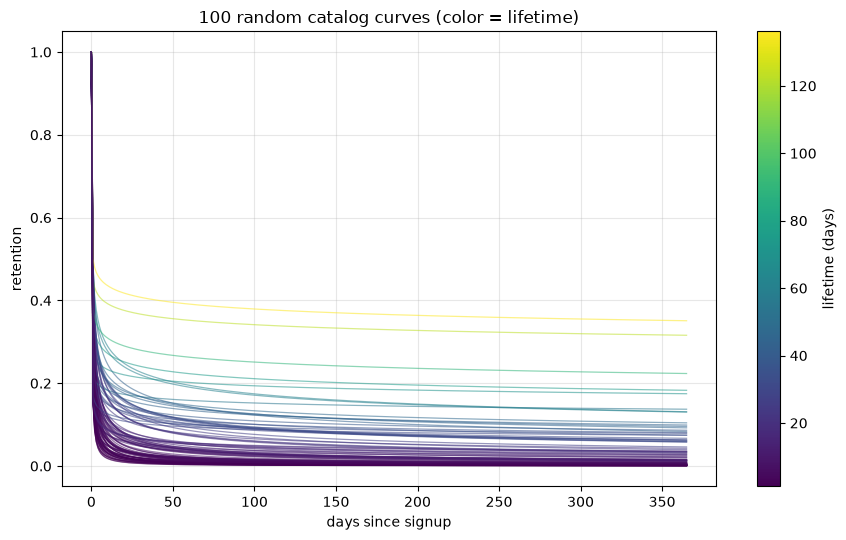

In [6]:
sample = catalog.sample(100, random_state=42)
day_cols = [f'D{t}' for t in range(DAYS + 1)]

fig, ax = plt.subplots(figsize=(9, 5.5))
norm = plt.Normalize(sample['lifetime'].min(), sample['lifetime'].max())
cmap = plt.cm.viridis
for _, row in sample.iterrows():
    ax.plot(range(DAYS + 1), row[day_cols].to_numpy(dtype=float),
            color=cmap(norm(row['lifetime'])), alpha=0.55, linewidth=0.9)
ax.set_title('100 random catalog curves (color = lifetime)')
ax.set_xlabel('days since signup'); ax.set_ylabel('retention')
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, label='lifetime (days)')
plt.tight_layout(); plt.show()

모든 곡선이 D0=1.0에서 출발하여 설정된 D1 Anchor로 내려앉은 후, b에 따라 서로 다른 두께의
꼬리를 형성합니다. 차원별 역할을 나누어 살펴보면 파라미터의 특성이 더욱 명확해집니다.

- **D1 Anchor(왼쪽)**: 곡선의 높낮이를 조절하는 역할을 합니다.
- **파라미터 b(오른쪽)**: 같은 D1에서 시작하더라도 꼬리의 두께(감소 폭의 경사)를 다르게 결정짓습니다.


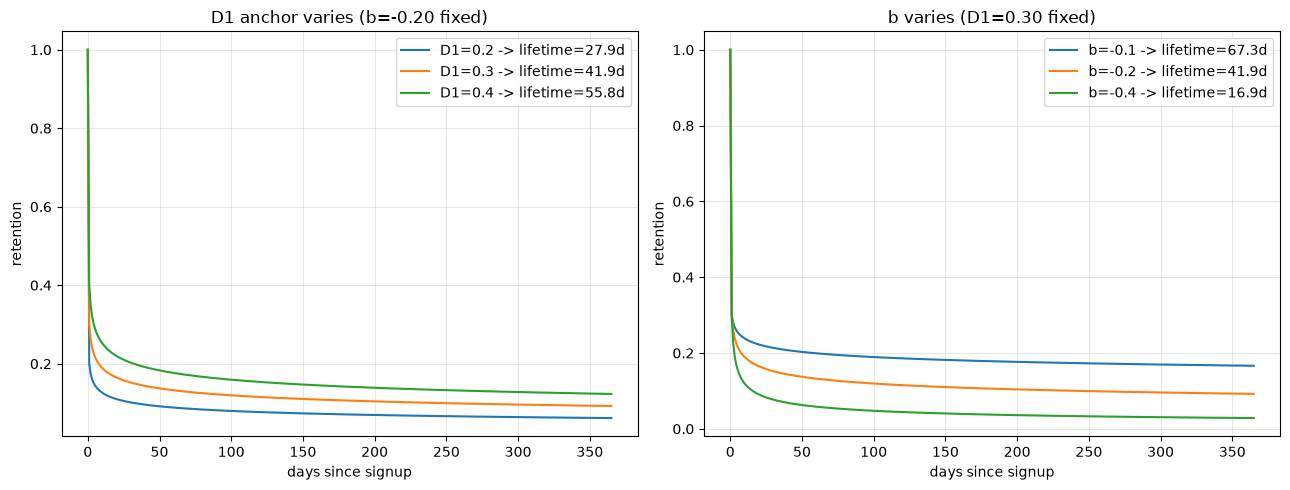

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for d1 in [0.20, 0.30, 0.40]:
    D = power_curve(-0.20, d1)
    axes[0].plot(D, label=f'D1={d1} -> lifetime={sum(D[1:]):.1f}d')
axes[0].set_title('D1 anchor varies (b=-0.20 fixed)')
axes[0].set_xlabel('days since signup'); axes[0].set_ylabel('retention')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for b in [-0.10, -0.20, -0.40]:
    D = power_curve(b, 0.30)
    axes[1].plot(D, label=f'b={b} -> lifetime={sum(D[1:]):.1f}d')
axes[1].set_title('b varies (D1=0.30 fixed)')
axes[1].set_xlabel('days since signup'); axes[1].set_ylabel('retention')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### 4.6.3.3. 최소 오차제곱합(SSE) 곡선 매칭

이제 카탈로그를 DuckDB에 등록하고, 신규 코호트의 관측값(D1, D3, D7)과의 오차제곱합(SSE, Sum of
Squared Errors)이 가장 작은 곡선을 정렬 쿼리로 찾습니다.

$$ \text{SSE} = (D_{1,\text{cat}} - D_{1,\text{obs}})^2 + (D_{3,\text{cat}} - D_{3,\text{obs}})^2 + (D_{7,\text{cat}} - D_{7,\text{obs}})^2 $$

> **[내 데이터 적용]** 매칭에 쓰는 관측 시점은 아래 SQL의 D1·D3·D7입니다. 더 긴 관측이 있으면 D14 등을
> 더해 식별력을 높일 수 있습니다(같은 D1·D3·D7에 가까운 곡선이 여럿일 수 있으므로).


In [8]:
con.register('lifetime_catalog', catalog)

catalog_match_query = """
WITH new_obs AS (
  SELECT
    MAX(CASE WHEN day = 1 THEN retention END) AS d1,
    MAX(CASE WHEN day = 3 THEN retention END) AS d3,
    MAX(CASE WHEN day = 7 THEN retention END) AS d7
  FROM cohort_retention
),
errors AS (
  SELECT cat.D1, cat.b, cat.lifetime,
         POWER(cat.D1 - obs.d1, 2) + POWER(cat.D3 - obs.d3, 2)
           + POWER(cat.D7 - obs.d7, 2) AS sse
  FROM lifetime_catalog AS cat CROSS JOIN new_obs AS obs
)
SELECT
  ROUND(D1, 2)       AS matched_d1,
  ROUND(b, 2)        AS matched_b,
  ROUND(sse, 6)      AS sse,
  ROUND(lifetime, 2) AS lifetime_estimate
FROM errors ORDER BY sse LIMIT 1
"""
catalog_match = con.execute(catalog_match_query).df()
catalog_match

,matched_d1,matched_b,sse,lifetime_estimate
0,0.34,-0.18,0.000057,52.15


### 4.6.3.4. 결과 해석


매칭된 파라미터 조합은 (D1=0.34, b=-0.18)이며, 이에 따른 최종 Lifetime 추정치는 약 **52.15일**입니다.

SSE는 0.000057로 매우 낮습니다. 복잡한 최적화 알고리즘이나 수식 없이도 간단한 SQL 거리
계산(SSE)만으로 3,456개 사전 정의 곡선 중 가장 유사한 형태를 골라낼 수 있습니다. 이것이 이
접근법의 가장 큰 실무적 장점입니다.


## 4.6.4. 장기 코호트 직접 측정

세 번째 방법은 1년 전 장기 코호트(Mature Cohort)의 실측 Lifetime 데이터를 기준선으로 활용하되,
신규 코호트와의 초기 7일간 성능 차이(비율)만큼 보정(Scaling)해서 추정하는 방식입니다.

이 방법을 적용하려면 서비스 내 1년 이상의 리텐션 데이터 마트가 구축되어 있어야 합니다. 이
실습에서는 장기 코호트의 실측 지표를 다음과 같이 가정하고 진행합니다.

| 구분 | 정의 | 계산 방식 | 값 |
| :-- | :-- | :-- | --: |
| `lifetime_mature` | 장기 코호트의 1년 치 실측 lifetime | sum(retention) over D1~D365 | 51.5 |
| `area_d1_d7_mature` | 장기 코호트의 D1~D7 면적 | sum(retention) over D1~D7 | 1.875 |

> **[내 데이터 적용]** 장기(1년+) 코호트의 실측 값입니다. 운영 데이터가 있다면 두 값을 코호트 리텐션
> 마트에서 직접 뽑아 넣습니다 — `lifetime_mature` = D1~D365 합, `area_d1_d7_mature` = D1~D7 합.


### 4.6.4.1. 초기 면적 비율 보정을 통한 Lifetime 추정

D7 한 시점의 리텐션만 비교하기보다, D1~D7 구간 전체 면적(AUC)의 비율을 사용하는 것이 일별
변동성(노이즈)에 둔감하여 훨씬 안정적입니다. 아래 식으로 보정 계수(Scaling Factor)를 구합니다.

$$ \text{Scaling Factor} = \frac{\text{Area}_{D1\text{-}D7}\text{ (New)}}{\text{Area}_{D1\text{-}D7}\text{ (Mature)}} $$

$$ \text{Lifetime Estimate} = \text{Lifetime}_{\text{Mature}} \times \text{Scaling Factor} $$


In [9]:
mature_query = """
WITH params AS (
  SELECT 51.5 AS lifetime_mature, 1.875 AS area_d1_d7_mature
),
new_area AS (
  SELECT SUM(retention) AS area_d1_d7_new
  FROM cohort_retention
  WHERE day BETWEEN 1 AND 7
)
SELECT
  p.lifetime_mature,
  p.area_d1_d7_mature,
  ROUND(n.area_d1_d7_new, 4) AS area_d1_d7_new,
  ROUND(n.area_d1_d7_new / p.area_d1_d7_mature, 4) AS scaling_factor,
  ROUND(p.lifetime_mature * n.area_d1_d7_new / p.area_d1_d7_mature, 2)
    AS lifetime_estimate
FROM new_area AS n CROSS JOIN params AS p
"""
mature = con.execute(mature_query).df()
mature

,lifetime_mature,area_d1_d7_mature,area_d1_d7_new,scaling_factor,lifetime_estimate
0,51.5,1.875,1.912,1.0197,52.52


### 4.6.4.2. 결과 해석


신규 코호트의 초기 D1~D7 면적(1.912)이 장기 코호트(1.875)보다 약 1.97% 높아, 보정 계수(Scaling
Factor)는 1.0197이 나옵니다. 이 보정 계수를 장기 코호트의 1년 실측 Lifetime(51.5일)에 곱해주면,
신규 코호트의 추정 Lifetime은 약 **52.52일**이 됩니다.

이 방식의 가장 큰 장점은 복잡한 통계·수학적 가정이나 추론 모델이 거의 들어가지 않는다는
점입니다. 실제로 유저가 1년 동안 행동한 잔존 데이터를 있는 그대로 가져오고, 초기 성과 차이만
비율로 보정하기 때문에 직관적이며 이해관계자를 설득하기도 쉽습니다.


## 4.6.5. 세 방법 결과 비교

앞서 다룬 세 가지 추정 방법(이탈률 휴리스틱, 리텐션 카탈로그 매칭, 장기 코호트 직접 측정)의
결과를 나란히 모아 비교해 보겠습니다.

> **[내 데이터 적용]** 세 방법의 결과 변수를 그대로 재사용하므로, 각 단계에서 내 값으로 바꿔
> 실행하면 이 비교표에 자동으로 반영됩니다.


In [10]:
# 앞에서 계산한 결과(heuristic·catalog_match·mature)를 그대로 재사용합니다
compare = pd.DataFrame({
    'method': ['1) 이탈률 휴리스틱', '2) 리텐션 카탈로그 매칭',
               '3) 장기 코호트 직접 측정'],
    'lifetime': [heuristic['lifetime_estimate'][0],
                 catalog_match['lifetime_estimate'][0],
                 mature['lifetime_estimate'][0]],
})
compare

,method,lifetime
0,1) 이탈률 휴리스틱,13.33
1,2) 리텐션 카탈로그 매칭,52.15
2,3) 장기 코호트 직접 측정,52.52


세 가지 추정치를 그래프로 비교해보면 다음과 같습니다.


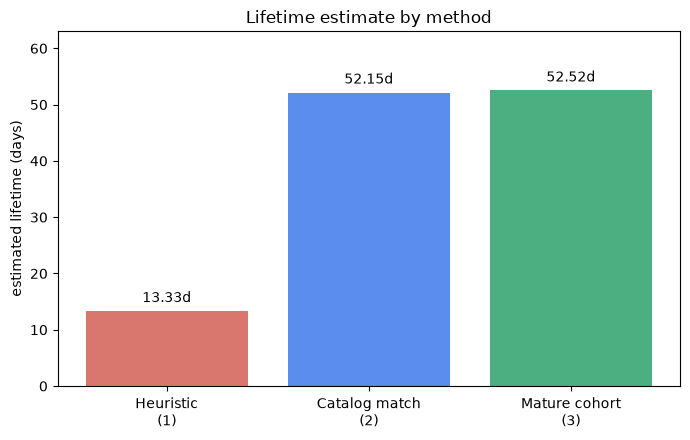

In [11]:
labels = ['Heuristic\n(1)', 'Catalog match\n(2)', 'Mature cohort\n(3)']
values = compare['lifetime'].tolist()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=['#d9776f', '#5b8def', '#4caf82'])
ax.set_ylabel('estimated lifetime (days)')
ax.set_title('Lifetime estimate by method')
ax.set_ylim(0, max(values) * 1.2)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.2f}d',
            ha='center', va='bottom')
plt.tight_layout(); plt.show()

동일한 신규 코호트의 초기 7일 데이터로 추정했는데도, 결과는 **13.3일 vs 52.2일 vs 52.5일**로
크게 차이가 납니다.

엄밀히 말하면 현시점에서는 무엇이 진실(Ground Truth)인지 알 수 없습니다. 신규 코호트가
만들어지고 나서 1년을 기다려야 실측 정답이 나오는데, 우리에게는 7일 치 데이터밖에 없기
때문입니다. 추정의 정확도를 확인하려면 358일을 더 기다려야 합니다. 대신 우리가 할 수 있는 것은
각 방식이 내포한 '수학적/통계적 가정'이 어떻게 달랐기에 이런 격차가 발생했는지 파악하는 것입니다.


### 4.6.5.1. 휴리스틱이 13.3일로 현저히 작게 산출된 이유

**두꺼운 꼬리 미반영**: 일정 비율(r)로 감소한다는 등비급수 가정은 리텐션 곡선 후반부의 '두꺼운
꼬리'를 표현하지 못합니다. 실제 리텐션 곡선은 시간이 흐를수록 남아 있는 핵심 유저들의 잔류
경향이 강해져 일간 잔존비율(r)이 점점 1에 가까워집니다. 그러나 휴리스틱은 D5~D7 구간에서 잰
r=0.979를 그 뒤로 끝까지 똑같이 곱하기 때문에, 후반부 Lifetime을 과소추정하게 됩니다.


### 4.6.5.2. 카탈로그 매칭과 장기 코호트가 약 52일로 수렴한 이유

출발점은 서로 다르지만, 두 방법 모두 리텐션 곡선 후반부의 장기 유저 특성(Heavy Tail)을 반영한다는
공통점이 있습니다.

- **카탈로그 매칭**: 멱함수는 일간 잔존비율이 매일 1에 가까워지는 형태라 두꺼운 꼬리가 모형 안에 내장되어 있습니다.
- **장기 코호트 측정**: 작년에 가입한 실제 유저들의 1년 치 행동 데이터(`lifetime_mature`)를 쓰기 때문에 곡선 끝부분이 이미 실측치로 들어있습니다.

실무에서 단 하나의 모델에만 의존하면 모델의 기본 가정이 틀렸을 때 분석 결과 전체가 크게 왜곡될
위험이 있습니다. 반면, 가정이 서로 다른 둘 이상의 모델이 비슷한 결과를 내놓는다면 추정치의
신뢰도는 훨씬 높아집니다. 일종의 '삼각측량(Triangulation)' 방식이라고 할 수 있습니다.

이번 실습에서는 카탈로그 매칭(52.15일)과 장기 코호트 측정(52.52일)이 거의 동일한 값을
가리켰습니다. 독립된 두 모델이 같은 수치로 수렴한 것은 휴리스틱 추정치(13.3일)가 지나치게 낮게
나왔다고 볼 근거가 됩니다.


## 4.6.6. 세 가지 접근법의 교차 검증

이상으로 Lifetime을 예측하는 세 가지 접근법을 실습을 통해 살펴보았습니다. 만약 ARPDAU가
0.015달러라면 휴리스틱의 13일은 유저당 LTV 약 0.2달러, 카탈로그와 장기 코호트의 52일은 약
0.78달러가 됩니다. 어느 숫자를 믿느냐에 따라 마케팅 CAC 상한선이 네 배 가까이 달라지는 셈입니다.

여기서 한 가지 명심해야 할 점이 있습니다. 그 어떤 고급 추론 알고리즘이나 고도화된 통계
기법이라도, 데이터 본질에 내재된 불확실성을 100% 제거할 수는 없다는 사실입니다. 모형은
어디까지나 현실을 모사한 도구일 뿐입니다. 따라서 실무에서 LTV나 Lifetime 추정치를 다룰 때는
다음 두 가지 원칙을 반드시 기억해야 합니다.

1. **단일 추정치를 절대적인 진리(Absolute Ground Truth)로 과신하지 말 것**: 하나의 수치에
   과도한 확신을 가지면 잘못된 의사결정을 할 수 있습니다.
2. **두 가지 이상의 추정 방식을 교차 비교할 것**: 서로 다른 가정을 가진 모델들을 함께
   검증해야 추정치의 불확실성을 줄이고 신뢰도를 확보할 수 있습니다.
